<a href="https://colab.research.google.com/github/woo-dh/Sliding-and-rolling-along-circular-tracks-in-a-vertical-plane/blob/main/Sliding_and_rolling_along_circular_tracks_in_a_vertical_plane.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 필요한 라이브러리를 불러옵니다.
import math  # 삼각함수와 라디안 변환을 사용하기 위한 라이브러리입니다.
import pandas as pd  # 표 형태의 데이터를 만들고 저장하기 위한 라이브러리입니다.
import matplotlib.pyplot as plt  # 그래프를 그리기 위한 라이브러리입니다.

# 기본 물리 상수를 설정합니다.
g = 9.81  # 중력가속도입니다. 단위는 m/s^2입니다.

# 실험 조건을 설정합니다.
theta_60 = math.radians(60)  # 60도 경사면의 각도를 라디안으로 변환합니다.
theta_30 = math.radians(30)  # 30도 경사면의 각도를 라디안으로 변환합니다.

# 당구공 관련 값을 설정합니다.
r_ball = 0.0254  # 당구공의 실제 반지름입니다. 단위는 m입니다.
r_rolling = 0.0230  # 트랙 위에서의 유효 구름 반지름입니다. 단위는 m입니다.
mass = 1.0  # 질량은 상대적 에너지 비교용으로 1 kg으로 둡니다.

# 관성모멘트를 계산합니다.
moment_factor = 2 / 5  # 속이 찬 구의 관성모멘트 계수입니다.
inertia = moment_factor * mass * r_ball ** 2  # I = 2/5 * m * r^2 공식을 사용합니다.

# 시간 조건을 설정합니다.
dt = 0.001  # 시간 간격입니다. 단위는 초입니다.
total_time = 2.0  # 전체 시뮬레이션 시간입니다. 단위는 초입니다.
steps = int(total_time / dt)  # 반복 횟수를 계산합니다.

# 초기 운동 상태를 설정합니다.
v = 0.0  # 초기 선속도입니다. 단위는 m/s입니다.
omega = 0.0  # 초기 각속도입니다. 단위는 rad/s입니다.
height = 0.20  # 초기 높이입니다. 단위는 m입니다.

# 결과를 저장할 리스트를 만듭니다.
results = []  # 시간별 시뮬레이션 결과를 저장할 빈 리스트입니다.

# 시간에 따라 공의 운동을 계산합니다.
for i in range(steps + 1):  # 0초부터 total_time까지 반복합니다.
    t = i * dt  # 현재 시간을 계산합니다.

    if t < 0.26:  # 처음 0.26초까지는 60도 경사면을 내려오는 구간입니다.
        section = "60-degree incline"  # 현재 구간 이름을 저장합니다.
        acceleration = 6.61  # 논문에서 제시된 측정 가속도 약 6.61 m/s^2를 사용합니다.
        v = v + acceleration * dt  # 선속도를 증가시킵니다.
        omega = omega + (0.35 * acceleration / r_rolling) * dt  # 미끄러짐 상태를 반영해 각속도는 천천히 증가시킵니다.
        height = max(0.0, height - v * math.sin(theta_60) * dt)  # 경사면을 내려오므로 높이를 감소시킵니다.

    elif t < 0.35:  # 0.26초부터 0.35초까지는 첫 번째 곡선 구간입니다.
        section = "first curved section"  # 현재 구간 이름을 저장합니다.
        v = v * 0.992  # 곡선 구간에서 마찰 때문에 선속도가 감소하도록 설정합니다.
        omega = omega + 45.0 * dt  # 마찰이 회전을 증가시키므로 각속도를 빠르게 증가시킵니다.
        height = max(0.0, height - 0.15 * dt)  # 곡선 아래쪽으로 이동한다고 보고 높이를 조금 감소시킵니다.

    elif t < 0.70:  # 0.35초부터 0.70초까지는 30도 경사면을 올라가는 구간입니다.
        section = "up 30-degree incline"  # 현재 구간 이름을 저장합니다.
        acceleration = -g * math.sin(theta_30) * 0.55  # 경사면을 올라가며 감속하는 효과를 설정합니다.
        v = max(0.0, v + acceleration * dt)  # 선속도를 줄이되 음수가 되지 않게 합니다.
        omega = v / r_rolling  # 구름운동에 가까워졌다고 보고 omega를 v/r로 맞춥니다.
        height = height + v * math.sin(theta_30) * dt  # 30도 경사면을 올라가므로 높이를 증가시킵니다.

    elif t < 1.13:  # 0.70초부터 1.13초까지는 30도 경사면을 다시 내려오는 구간입니다.
        section = "down 30-degree incline"  # 현재 구간 이름을 저장합니다.
        acceleration = g * math.sin(theta_30) * 0.55  # 30도 경사면을 내려오며 가속하는 효과를 설정합니다.
        v = v + acceleration * dt  # 선속도를 증가시킵니다.
        omega = v / r_rolling  # 이미 구름운동에 가까운 상태로 보고 omega를 v/r로 맞춥니다.
        height = max(0.0, height - v * math.sin(theta_30) * dt)  # 내려오므로 높이를 감소시킵니다.

    elif t < 1.32:  # 1.13초부터 1.32초까지는 두 번째 곡선 구간입니다.
        section = "second curved section"  # 현재 구간 이름을 저장합니다.
        v = v * 0.998  # 이미 굴러가는 상태이므로 선속도 감소를 작게 설정합니다.
        omega = v / r_rolling  # 구름운동 조건에 맞게 각속도를 계산합니다.
        height = max(0.0, height - 0.05 * dt)  # 높이를 조금 감소시킵니다.

    elif t < 1.60:  # 1.32초부터 1.60초까지는 60도 경사면 쪽으로 올라가는 구간입니다.
        section = "up 60-degree incline"  # 현재 구간 이름을 저장합니다.
        acceleration = -g * math.sin(theta_60) * 0.55  # 60도 경사면을 올라가며 감속하는 효과를 설정합니다.
        v = max(0.0, v + acceleration * dt)  # 선속도를 줄이되 음수가 되지 않게 합니다.
        omega = v / r_rolling  # 구름운동 조건에 맞게 각속도를 계산합니다.
        height = height + v * math.sin(theta_60) * dt  # 60도 경사면을 올라가므로 높이를 증가시킵니다.

    else:  # 1.60초 이후는 마지막 감쇠 구간입니다.
        section = "final motion"  # 현재 구간 이름을 저장합니다.
        v = v * 0.995  # 마찰 때문에 선속도가 점점 감소하도록 설정합니다.
        omega = v / r_rolling if v > 0 else 0.0  # 선속도가 있으면 구름조건으로 각속도를 계산합니다.
        height = max(0.0, height - 0.01 * dt)  # 높이가 음수가 되지 않도록 감소시킵니다.

    if omega > 0:  # 각속도가 0보다 클 때만 나눗셈을 합니다.
        ratio = v / omega  # v/omega 값을 계산합니다.
    else:  # 각속도가 0이면 나눗셈이 불가능합니다.
        ratio = 0.0  # 초기값으로 0을 저장합니다.

    potential_energy = mass * g * height  # 위치에너지를 계산합니다.
    translational_energy = 0.5 * mass * v ** 2  # 병진 운동에너지를 계산합니다.
    rotational_energy = 0.5 * inertia * omega ** 2  # 회전 운동에너지를 계산합니다.
    total_energy = potential_energy + translational_energy + rotational_energy  # 전체 역학적 에너지를 계산합니다.

    results.append({
        "time": t,  # 현재 시간을 저장합니다.
        "section": section,  # 현재 구간 이름을 저장합니다.
        "height": height,  # 현재 높이를 저장합니다.
        "v": v,  # 현재 선속도를 저장합니다.
        "omega": omega,  # 현재 각속도를 저장합니다.
        "v_over_omega": ratio,  # 현재 v/omega 값을 저장합니다.
        "potential_energy": potential_energy,  # 위치에너지를 저장합니다.
        "translational_energy": translational_energy,  # 병진 운동에너지를 저장합니다.
        "rotational_energy": rotational_energy,  # 회전 에너지를 저장합니다.
        "total_energy": total_energy  # 전체 역학적 에너지를 저장합니다.
    })

# 리스트 형태의 결과를 표 형태 데이터프레임으로 바꿉니다.
df = pd.DataFrame(results)  # 결과 리스트를 pandas DataFrame으로 변환합니다.

# 시뮬레이션 결과 일부를 화면에 출력합니다.
df.head()  # 처음 5개 행을 보여줍니다.

,time,section,height,v,omega,v_over_omega,potential_energy,translational_energy,rotational_energy,total_energy
0,0.000,60-degree incline,0.199994,0.00661,0.100587,0.065714,1.961944,0.000022,0.000001,1.961967
1,0.001,60-degree incline,0.199983,0.01322,0.201174,0.065714,1.961832,0.000087,0.000005,1.961924
2,0.002,60-degree incline,0.199966,0.01983,0.301761,0.065714,1.961663,0.000197,0.000012,1.961871
3,0.003,60-degree incline,0.199943,0.02644,0.402348,0.065714,1.961438,0.000350,0.000021,1.961809
4,0.004,60-degree incline,0.199914,0.03305,0.502935,0.065714,1.961158,0.000546,0.000033,1.961736


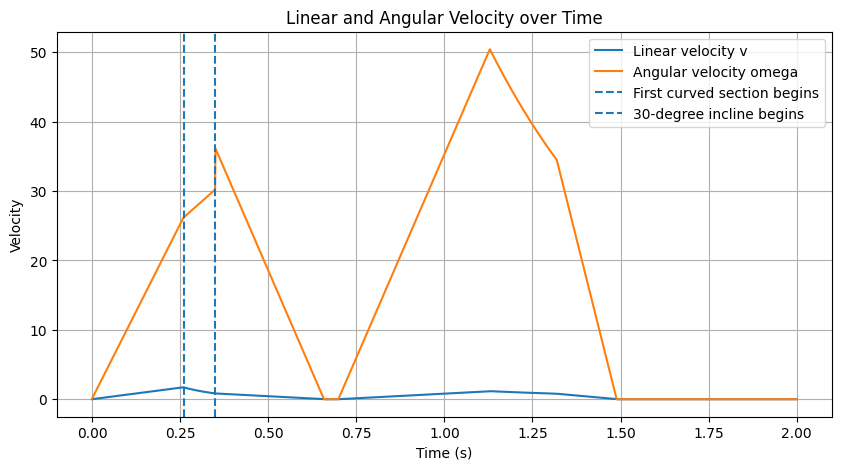

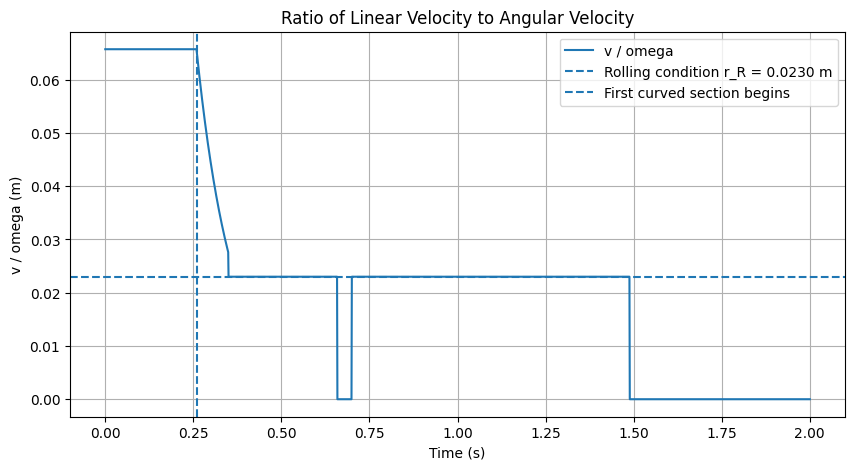

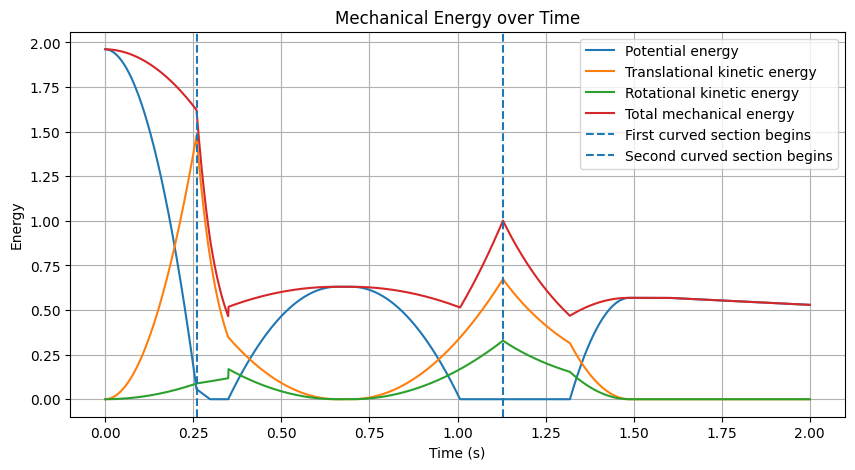

In [3]:
# 그래프 1: 선속도와 각속도 변화를 그립니다.
plt.figure(figsize=(10, 5))  # 그래프 크기를 설정합니다.
plt.plot(df["time"], df["v"], label="Linear velocity v")  # 시간에 따른 선속도를 그립니다.
plt.plot(df["time"], df["omega"], label="Angular velocity omega")  # 시간에 따른 각속도를 그립니다.
plt.axvline(x=0.26, linestyle="--", label="First curved section begins")  # 첫 번째 곡선 구간 시작 시점을 표시합니다.
plt.axvline(x=0.35, linestyle="--", label="30-degree incline begins")  # 30도 경사면 시작 시점을 표시합니다.
plt.xlabel("Time (s)")  # x축 이름을 설정합니다.
plt.ylabel("Velocity")  # y축 이름을 설정합니다.
plt.title("Linear and Angular Velocity over Time")  # 그래프 제목을 설정합니다.
plt.legend()  # 범례를 표시합니다.
plt.grid(True)  # 격자선을 표시합니다.
plt.show()  # 그래프를 화면에 출력합니다.

# 그래프 2: v/omega 비율 변화를 그립니다.
plt.figure(figsize=(10, 5))  # 그래프 크기를 설정합니다.
plt.plot(df["time"], df["v_over_omega"], label="v / omega")  # 시간에 따른 v/omega 값을 그립니다.
plt.axhline(y=0.0230, linestyle="--", label="Rolling condition r_R = 0.0230 m")  # 구름운동 조건 기준선을 표시합니다.
plt.axvline(x=0.26, linestyle="--", label="First curved section begins")  # 첫 번째 곡선 구간 시작 시점을 표시합니다.
plt.xlabel("Time (s)")  # x축 이름을 설정합니다.
plt.ylabel("v / omega (m)")  # y축 이름을 설정합니다.
plt.title("Ratio of Linear Velocity to Angular Velocity")  # 그래프 제목을 설정합니다.
plt.legend()  # 범례를 표시합니다.
plt.grid(True)  # 격자선을 표시합니다.
plt.show()  # 그래프를 화면에 출력합니다.

# 그래프 3: 에너지 변화를 그립니다.
plt.figure(figsize=(10, 5))  # 그래프 크기를 설정합니다.
plt.plot(df["time"], df["potential_energy"], label="Potential energy")  # 위치에너지 그래프를 그립니다.
plt.plot(df["time"], df["translational_energy"], label="Translational kinetic energy")  # 병진 운동에너지 그래프를 그립니다.
plt.plot(df["time"], df["rotational_energy"], label="Rotational kinetic energy")  # 회전 에너지 그래프를 그립니다.
plt.plot(df["time"], df["total_energy"], label="Total mechanical energy")  # 전체 에너지 그래프를 그립니다.
plt.axvline(x=0.26, linestyle="--", label="First curved section begins")  # 첫 번째 곡선 구간 시작 시점을 표시합니다.
plt.axvline(x=1.13, linestyle="--", label="Second curved section begins")  # 두 번째 곡선 구간 시작 시점을 표시합니다.
plt.xlabel("Time (s)")  # x축 이름을 설정합니다.
plt.ylabel("Energy")  # y축 이름을 설정합니다.
plt.title("Mechanical Energy over Time")  # 그래프 제목을 설정합니다.
plt.legend()  # 범례를 표시합니다.
plt.grid(True)  # 격자선을 표시합니다.
plt.show()  # 그래프를 화면에 출력합니다.